# Анализ отзывов клиентов T-Bank

Исследую отзывы клиентов и ищу основные источники негатива.
Сравниваю группы и проверяю связь факторов с тональностью.



In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency

DATA_PATH = "data/customer_reviews.xlsx"
MIN_REVIEWS = 200

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Загрузка и подготовка данных

In [2]:
reviews = pd.read_excel(DATA_PATH)
reviews["review_dttm"] = pd.to_datetime(reviews["review_dttm"], errors="coerce")
reviews["finish_dttm"] = pd.to_datetime(reviews["finish_dttm"], errors="coerce")
reviews["is_negative"] = (reviews["review_emotion"] == "Негативный").astype(int)
reviews["month"] = reviews["review_dttm"].dt.to_period("M").astype(str)
reviews["processing_hours"] = (
    reviews["finish_dttm"] - reviews["review_dttm"]
).dt.total_seconds() / 3600
reviews.loc[reviews["processing_hours"] < 0, "processing_hours"] = np.nan

print(reviews.shape)
print(f"Повторы строк: {reviews.duplicated().sum():,}")
display(reviews.head())

(56820, 28)
Повторы строк: 0


,review_dttm,finish_dttm,id_client,company,review_mark,review_emotion,review_source,business_line,product,reason,review_theme,subtheme,review_text,solution_flg,gender_cd,education_level_cd,marital_status_cd,children_cnt,citizenship_country,segment_name,subscription_important_flg,new_flg,influencer_flg,age_segment,csat_score,is_negative,month,processing_hours
0,2025-02-18 15:41:00,2025-02-18 16:56:49.353,fb30834209a9c7f60612c64b82c75ffa,Банк,1,Негативный,banki.ru,кредитные карты,кредитная карта,Не определено,тарифы и условия,консультация по продукту,"Непрозрачные условия, скрытые комсисии. Почему...",проблема решена,M,NaN,UNM,0.0,РФ,Доходные,0.0,0.0,0.0,Молодежь,NaN,1,2025-02,1.263709
1,2025-03-24 20:06:00,2025-03-28 17:42:39.772,6601bfab426e4f56cc1e44d859683763,Страховая,1,Негативный,banki.ru,страховая,каско,Не определено,страховое событие,жалоба по страховому случаю,"Обратился по каско , влетел камень в лобовое с...",проблема решена,M,NaN,NaN,NaN,РФ,NaN,NaN,NaN,NaN,NaN,NaN,1,2025-03,93.611048
2,2025-07-08 07:40:43,2025-07-08 10:29:04.740,f1f8eff66eaf2289f61deec744871d6b,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,мп/лк/терминал,установка/обновление приложения,Я уже очень давно пользуюсь услугами Тбанка и ...,не указано,M,GRD,MAR,0.0,РФ,Малодоходные,0.0,0.0,0.0,Взрослые,NaN,0,2025-07,2.806039
3,2025-08-07 22:51:48,2025-08-08 09:35:34.593,5ca669878eaf593f68c10e163246357b,SME,5,Позитивный,banki.ru,sme,расчетный счет,Не определено,дополнительные услуги,консультация по услуге,"Уважаемое руководство Т- Банка,\n\n\nНастоящим...",не указано,F,GRD,MAR,0.0,РФ,Высокодоходные без ПМ,0.0,0.0,1.0,Взрослые,NaN,0,2025-08,10.729609
4,2025-02-13 21:38:40,2025-02-14 08:04:44.643,7a436100b113ce78c8a7a02974521a16,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,кэшбек,корректировка кэшбека,Выбрал на текущий месяц повышенный кэшбек на к...,не указано,M,NaN,NaN,0.0,РФ,Доходные,0.0,0.0,1.0,Сеньоры,NaN,0,2025-02,10.434623


In [3]:
summary = pd.Series({
    "Доля негативных отзывов": reviews["is_negative"].mean(),
    "Доля пропусков CSAT": reviews["csat_score"].isna().mean(),
    "Медианное время обработки, часы": reviews["processing_hours"].median(),
}).to_frame("value")
summary.loc[["Доля негативных отзывов", "Доля пропусков CSAT"], "value"] *= 100
display(summary.round(2))

,value
Доля негативных отзывов,39.24
Доля пропусков CSAT,94.00
"Медианное время обработки, часы",1.66


## 2. Структура отзывов и динамика по месяцам

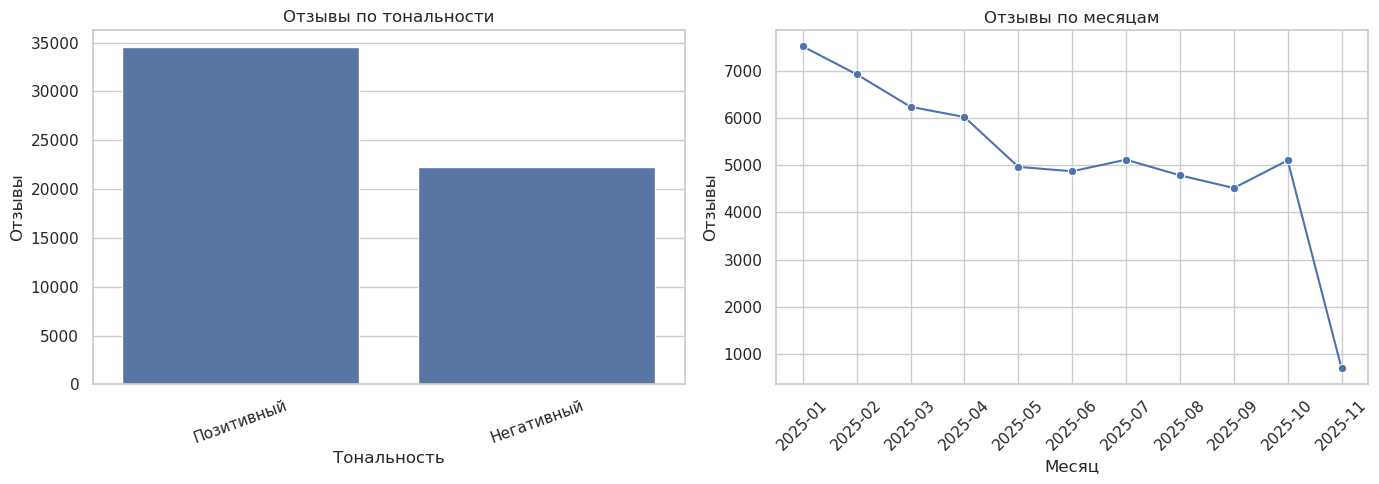

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emotion_counts = reviews["review_emotion"].value_counts()
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, ax=axes[0])
axes[0].set(title="Отзывы по тональности", xlabel="Тональность", ylabel="Отзывы")
axes[0].tick_params(axis="x", rotation=20)

monthly = reviews.groupby("month", as_index=False).size()
sns.lineplot(data=monthly, x="month", y="size", marker="o", ax=axes[1])
axes[1].set(title="Отзывы по месяцам", xlabel="Месяц", ylabel="Отзывы")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 3. Продукты и темы с высокой долей негатива

In [5]:
def negative_rate_table(data, group_column, min_reviews=MIN_REVIEWS):
    filtered = data.dropna(subset=[group_column])
    grouped = filtered.groupby(group_column)["is_negative"]

    result = grouped.size().to_frame("reviews")
    result["negative_reviews"] = grouped.sum()
    result["negative_rate"] = grouped.mean()
    result = result[result["reviews"] >= min_reviews]
    result = result.sort_values(["negative_rate", "reviews"], ascending=False)
    result = result.reset_index()
    result["negative_rate_pct"] = (result["negative_rate"] * 100).round(1)
    return result


product_risk = negative_rate_table(reviews, "product")
theme_risk = negative_rate_table(reviews, "review_theme")

display(product_risk.head(10))
display(theme_risk.head(10))

,product,reviews,negative_reviews,negative_rate,negative_rate_pct
0,кредит на покупку,214,194,0.906542,90.7
1,кредит наличными,492,445,0.904472,90.4
2,мобайл,778,696,0.894602,89.5
3,Не определено,698,594,0.851003,85.1
4,вклад,267,208,0.779026,77.9
5,lifestyle,258,196,0.759690,76.0
6,не определено,3410,2515,0.737537,73.8
7,кредитная карта,3064,2238,0.730418,73.0
8,автокредит в салонах,513,374,0.729045,72.9
9,автокредит наличными,320,230,0.718750,71.9


,review_theme,reviews,negative_reviews,negative_rate,negative_rate_pct
0,коммуникации клиентам,802,787,0.981297,98.1
1,погашение кредитных продуктов,1937,1871,0.965927,96.6
2,карты,4365,4099,0.939061,93.9
3,Не определено,1377,1265,0.918664,91.9
4,обеспечительные меры,579,464,0.801382,80.1
5,ценные бумаги,1055,845,0.800948,80.1
6,изменение данных,401,300,0.748130,74.8
7,нефинансовые услуги,207,145,0.700483,70.0
8,aml,2101,1353,0.643979,64.4
9,документы и справки,1016,654,0.643701,64.4


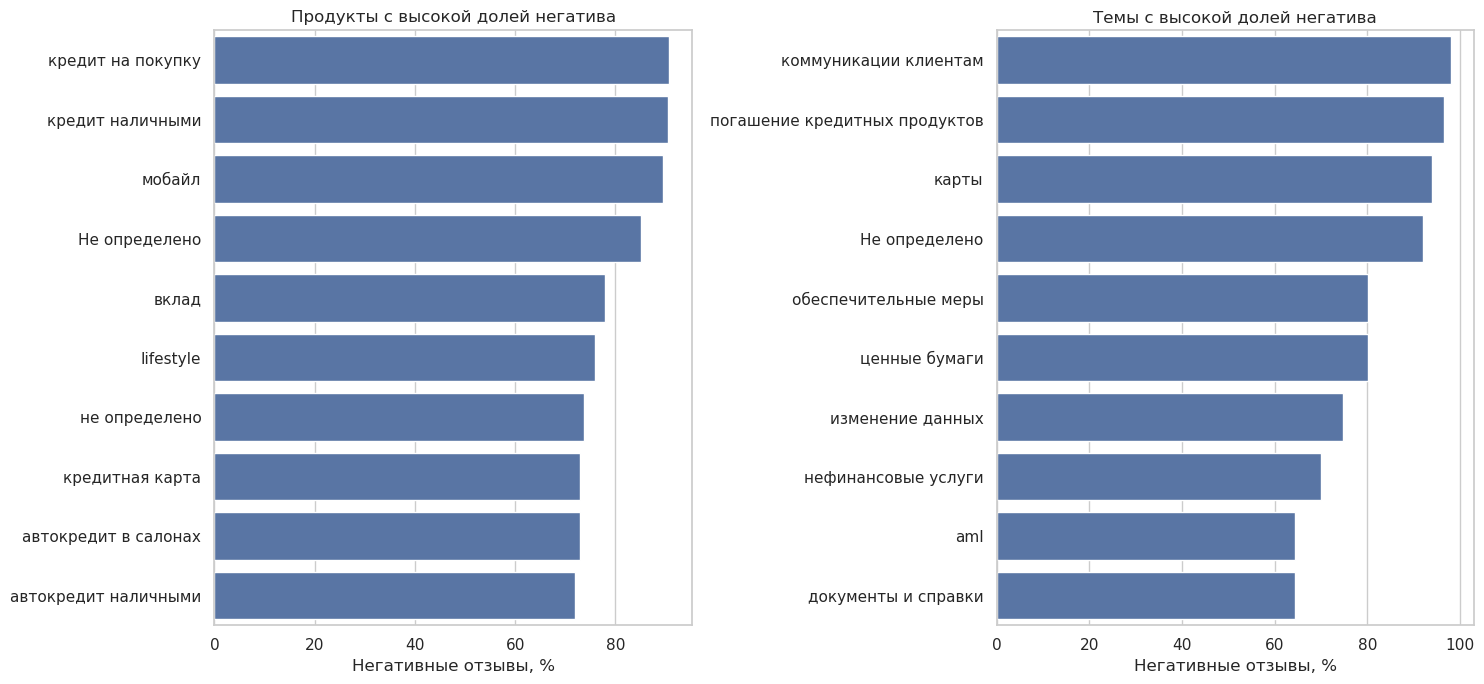

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.barplot(
    data=product_risk.head(10),
    x="negative_rate_pct",
    y="product",
    ax=axes[0],
)
axes[0].set(title="Продукты с высокой долей негатива", xlabel="Негативные отзывы, %", ylabel="")

sns.barplot(
    data=theme_risk.head(10),
    x="negative_rate_pct",
    y="review_theme",
    ax=axes[1],
)
axes[1].set(title="Темы с высокой долей негатива", xlabel="Негативные отзывы, %", ylabel="")

plt.tight_layout()
plt.show()

## 4. Сравнение групп клиентов

In [7]:
segment_labels = {
    "new_flg": {0: "Текущие", 1: "Новые"},
    "subscription_important_flg": {0: "Без премиальной подписки", 1: "С премиальной подпиской"},
    "influencer_flg": {0: "Обычный клиент", 1: "Инфлюенсер"},
}

segment_results = []
for column, labels in segment_labels.items():
    grouped = reviews.groupby(column)["is_negative"]
    table = grouped.size().to_frame("reviews")
    table["negative_rate"] = grouped.mean()
    table = table.reset_index()
    table["factor"] = column
    table["group"] = table[column].map(labels)
    segment_results.append(table[["factor", "group", "reviews", "negative_rate"]])

segments = pd.concat(segment_results, ignore_index=True)
segments["negative_rate_pct"] = (segments["negative_rate"] * 100).round(1)

display(segments)

,factor,group,reviews,negative_rate,negative_rate_pct
0,new_flg,Текущие,42666,0.432476,43.2
1,new_flg,Новые,942,0.530786,53.1
2,subscription_important_flg,Без премиальной подписки,41924,0.441346,44.1
3,subscription_important_flg,С премиальной подпиской,1684,0.266627,26.7
4,influencer_flg,Обычный клиент,29451,0.460901,46.1
5,influencer_flg,Инфлюенсер,14157,0.379883,38.0


## 5. Статистическая проверка

In [8]:
def chi_square_result(data, factor):
    table = pd.crosstab(data[factor], data["is_negative"])
    chi2, p_value, degrees, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    denominator = n * min(table.shape[0] - 1, table.shape[1] - 1)
    cramers_v = np.sqrt(chi2 / denominator) if denominator else np.nan
    return {
        "factor": factor,
        "chi_square": chi2,
        "degrees_of_freedom": degrees,
        "p_value": p_value,
        "cramers_v": cramers_v,
    }


factors = [
    "new_flg",
    "subscription_important_flg",
    "influencer_flg",
    "age_segment",
    "review_source",
]
test_results = pd.DataFrame([chi_square_result(reviews, factor) for factor in factors])
test_results["significant_at_5_pct"] = test_results["p_value"] < 0.05
display(test_results.sort_values("cramers_v", ascending=False).round(4))

,factor,chi_square,degrees_of_freedom,p_value,cramers_v,significant_at_5_pct
4,review_source,6968.3050,19,0.0,0.3502,True
2,influencer_flg,255.0741,1,0.0,0.0765,True
1,subscription_important_flg,200.4185,1,0.0,0.0678,True
3,age_segment,48.3281,5,0.0,0.0324,True
0,new_flg,35.8518,1,0.0,0.0287,True


## 6. Основные выводы

In [9]:
worst_product = product_risk.iloc[0]
worst_theme = theme_risk.iloc[0]
strongest_factor = test_results.sort_values("cramers_v", ascending=False).iloc[0]

print(f"Общая доля негативных отзывов: {reviews['is_negative'].mean():.1%}")
print(
    f"Продукт с наибольшей долей негатива среди продуктов минимум с {MIN_REVIEWS} отзывами: "
    f"{worst_product['product']} ({worst_product['negative_rate']:.1%})"
)
print(
    f"Тема с наибольшей долей негатива среди тем минимум с {MIN_REVIEWS} отзывами: "
    f"{worst_theme['review_theme']} ({worst_theme['negative_rate']:.1%})"
)
print(
    f"Самая сильная проверенная связь с тональностью: {strongest_factor['factor']} "
    f"(Cramer's V = {strongest_factor['cramers_v']:.3f})"
)

Общая доля негативных отзывов: 39.2%
Продукт с наибольшей долей негатива среди продуктов минимум с 200 отзывами: кредит на покупку (90.7%)
Тема с наибольшей долей негатива среди тем минимум с 200 отзывами: коммуникации клиентам (98.1%)
Самая сильная проверенная связь с тональностью: review_source (Cramer's V = 0.350)


### Итог

Анализ показывает продукты и темы, которые стоит проверить в первую очередь.
Статистические тесты помогают оценить связь факторов с тональностью,
а V Крамера — силу этой связи.
Дальше можно разобрать тексты отзывов в группах с высокой долей негатива
и выделить повторяющиеся проблемы.